# Análisis Comparativo de Estrategias de Decisión Multicriterio
## A Priori (GA) vs. A Posteriori (NSGA-II)

**MIAAD — Optimización Inteligente · UACJ**  
Javier Augusto Rebull Saucedo (263483)

Este notebook importa la lógica desde `src/` (sin duplicarla), muestra las cuatro soluciones, la gráfica comparativa y responde las cuatro preguntas del enunciado. Semilla fija (`seed=1`) para reproducibilidad.

In [1]:
import sys, os, json
from pathlib import Path
# Permitir importar el paquete src/ desde la raíz del repo
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
from src import aposteriori, apriori, visualization
print('Raíz del proyecto:', ROOT)

Raíz del proyecto: /Users/haowei/Documents/MIAAD/SMART/Multicriterio


## 1. Ejecución de ambas estrategias
Resolvemos el frente de Pareto con NSGA-II y aplicamos las post-selecciones (A Posteriori), y resolvemos el GA mono-objetivo con preferencias inyectadas (A Priori).

In [2]:
post = aposteriori.ejecutar(seed=1)
apri = apriori.ejecutar(seed=1)
print(f'Frente de Pareto: {len(post.F_pareto)} soluciones no dominadas')

Frente de Pareto: 100 soluciones no dominadas


## 2. Las cuatro soluciones seleccionadas

In [3]:
tabla = pd.DataFrame([
    ['A Posteriori', 'Suma Ponderada', *post.solucion_post_ponderada],
    ['A Posteriori', 'Lexicográfica', *post.solucion_post_lexicografica],
    ['A Priori', 'GA Ponderado', *apri.ponderada],
    ['A Priori', 'GA Lexicográfico', *apri.lexicografica],
], columns=['Enfoque', 'Criterio', 'f1 (Costo)', 'f2 (Tiempo)'])
tabla = tabla.round(2)
tabla

,Enfoque,Criterio,f1 (Costo),f2 (Tiempo)
0,A Posteriori,Suma Ponderada,20.18,23.32
1,A Posteriori,Lexicográfica,200.00,0.00
2,A Priori,GA Ponderado,18.00,24.50
3,A Priori,GA Lexicográfico,200.00,0.00


## 3. Visualización conjunta
Frente de Pareto (NSGA-II) y las cuatro decisiones. Las soluciones *ponderadas* caen en el codo del frente; las *lexicográficas* en el extremo de menor tiempo.

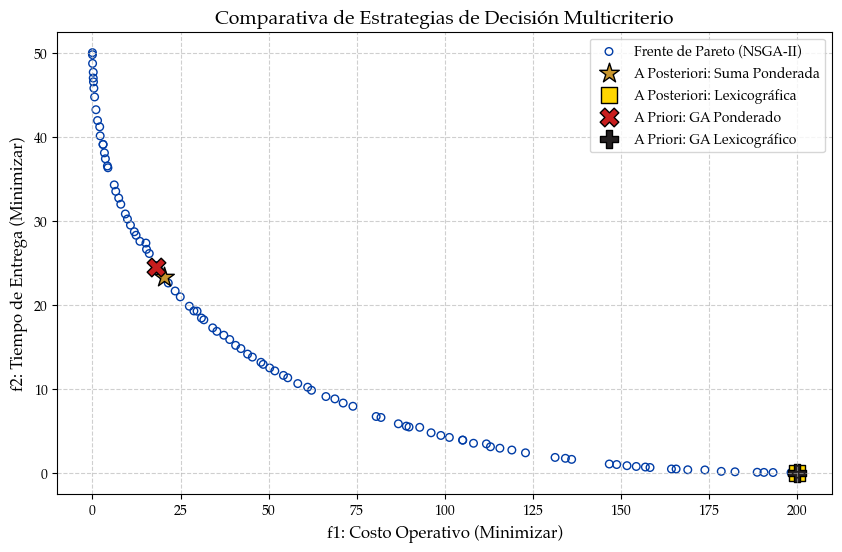

In [4]:
import matplotlib.pyplot as plt
from src import theme
fig, ax = plt.subplots(figsize=(10, 6))
F = post.F_pareto
ax.scatter(F[:,0], F[:,1], s=30, facecolors='none', edgecolors=theme.COLORS['pareto'], label=theme.LABELS['pareto'])
ax.scatter(*post.solucion_post_ponderada, marker='*', s=220, color=theme.COLORS['post_ponderada'], edgecolors='k', label=theme.LABELS['post_ponderada'])
ax.scatter(*post.solucion_post_lexicografica, marker='s', s=130, color=theme.COLORS['post_lexico'], edgecolors='k', label=theme.LABELS['post_lexico'])
ax.scatter(*apri.ponderada, marker='X', s=180, color=theme.COLORS['apriori_pond'], edgecolors='k', label=theme.LABELS['apriori_pond'])
ax.scatter(*apri.lexicografica, marker='P', s=180, color=theme.COLORS['apriori_lex'], edgecolors='k', label=theme.LABELS['apriori_lex'])
ax.set_title('Comparativa de Estrategias de Decisión Multicriterio')
ax.set_xlabel('f1: Costo Operativo (Minimizar)'); ax.set_ylabel('f2: Tiempo de Entrega (Minimizar)')
ax.grid(True, linestyle='--', alpha=0.6); ax.legend(loc='best')
plt.show()

## 4. Respuestas a las cuatro preguntas del enunciado

- [x] **P1 — Gráfica con leyenda visible:** mostrada arriba.
- [x] **P2 — Suma ponderada (a priori vs a posteriori):** las soluciones son muy cercanas (diferencia de pocas unidades). Coinciden porque el frente es **convexo**: cualquier minimización de la combinación lineal converge al mismo punto. Difieren levemente por el escalamiento manual ($f_1/200$, $f_2/50$) frente a la normalización por extremos del frente.
- [x] **P3 — Lexicográfica:** al minimizar sólo $f_2$ la solución va a $(5,5)$, donde $f_1$ alcanza su **máximo** (200). Coincide con el extremo de menor tiempo del frente NSGA-II.
- [x] **P4 — Conclusión profesional:** usar NSGA-II en decisiones estratégicas únicas con múltiples *stakeholders* y sin pesos consensuados; usar A Priori en decisiones operativas recurrentes con pesos estables.

In [5]:
# Verificación numérica (FASE 5): el frente toca los extremos teóricos
assert abs(F[:,0].min() - 0)   < 1e-2, 'min f1 debe ser ~0'
assert abs(F[:,1].min() - 0)   < 1e-2, 'min f2 debe ser ~0'
assert abs(apri.lexicografica[0] - 200) < 1.0, 'lex A Priori f1 debe ser ~200'
print('✔ Validación numérica superada: extremos y lexicográfica correctos.')

✔ Validación numérica superada: extremos y lexicográfica correctos.
